# PoC — Detecção de Técnicas de Manipulação Retórica em Discursos Políticos Brasileiros

## O que este notebook faz
1. Coleta discursos reais de deputados federais via API pública da Câmara
2. Aplica um LLM (GPT ou modelo local) para detectar técnicas de propaganda
3. Analisa quais técnicas aparecem mais por partido
4. Valida a viabilidade técnica e de dados do projeto de pesquisa

## Técnicas investigadas (baseadas no SemEval-2020 Task 11)
- **Name Calling**: rótulos pejorativos no adversário
- **Appeal to Fear**: criar medo para manipular
- **Loaded Language**: palavras emocionalmente carregadas
- **Whataboutism**: desviar crítica apontando outro problema
- **Causal Oversimplification**: causa única para problema complexo
- **Flag-waving**: apelo ao patriotismo/identidade de grupo
- **Appeal to Authority**: citar autoridade fora de contexto
- **Doubt**: semear dúvida sem evidência


In [19]:
import requests
import json
import time
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from openai import OpenAI
import os
import warnings
from dotenv import load_dotenv

warnings.filterwarnings("ignore")

load_dotenv()

client = OpenAI(api_key=os.environ.get("OPENAI_API_KEY"))

BASE_URL = "https://dadosabertos.camara.leg.br/api/v2"
plt.rcParams["figure.figsize"] = (12, 6)
sns.set_theme(style="whitegrid")

key = os.environ.get("OPENAI_API_KEY", "")
print("imports OK")


imports OK


In [ ]:
DEPUTADOS = [
    # Esquerda / PT
    (160508, "Afonso Florence",     "PT",  "esquerda"),
    (204501, "Alencar Santana",     "PT",  "esquerda"),
    (220554, "Alexandre Lindenmeyer","PT", "esquerda"),
    # Direita / PL
    (221328, "Adilson Barroso",     "PL",  "direita"),
    (73579,  "Alberto Fraga",       "PL",  "direita"),
    (220657, "André Fernandes",     "PL",  "direita"),
]

def coletar_discursos(dep_id: int, nome: str, partido: str, espectro: str,
                      data_inicio="2024-03-01", data_fim="2024-06-30",
                      max_discursos=5) -> list[dict]:
    """Coleta discursos de um deputado via ap i da Câmara."""
    url = f"{BASE_URL}/deputados/{dep_id}/discursos"
    params = {
        "dataInicio": data_inicio,
        "dataFim": data_fim,
        "itens": max_discursos,
        "ordem": "DESC",
        "ordenarPor": "dataHoraInicio"
    }
    try:
        resp = requests.get(url, params=params, timeout=15)
        resp.raise_for_status()
        dados = resp.json().get("dados", [])
        discursos = []
        for d in dados:
            transcricao = d.get("transcricao", "").strip()
            if len(transcricao) > 200:
                discursos.append({
                    "dep_id":    dep_id,
                    "nome":      nome,
                    "partido":   partido,
                    "espectro":  espectro,
                    "data":      d.get("dataHoraInicio", ""),
                    "sumario":   d.get("sumario", ""),
                    "texto":     transcricao[:3000],  
                    "keywords":  d.get("keywords", ""),
                })
        return discursos
    except Exception as e:
        print(f"  ⚠️  Erro ao coletar {nome}: {e}")
        return []


print(" coletando discursos da API da Câmara...")
todos_discursos = []

for dep_id, nome, partido, espectro in DEPUTADOS:
    discursos = coletar_discursos(dep_id, nome, partido, espectro)
    print(f"  {nome} ({partido}): {len(discursos)} discursos coletados")
    todos_discursos.extend(discursos)
    time.sleep(0.5)  

print(f"\n Total: {len(todos_discursos)} discursos coletados")


⏳ Coletando discursos da API da Câmara...
  Afonso Florence (PT): 0 discursos coletados
  Alencar Santana (PT): 5 discursos coletados
  Alexandre Lindenmeyer (PT): 3 discursos coletados
  Adilson Barroso (PL): 0 discursos coletados
  Alberto Fraga (PL): 5 discursos coletados
  André Fernandes (PL): 4 discursos coletados

✅ Total: 17 discursos coletados


In [ ]:
TECNICAS = {
    "name_calling":             "Uso de rótulos pejorativos ou insultos para desqualificar o adversário (ex: 'comunistas', 'fascistas', 'ladrões', 'golpistas')",
    "appeal_to_fear":           "Criar ou amplificar medo para manipular a audiência (ex: 'vão destruir sua família', 'o país vai virar Venezuela')",
    "loaded_language":          "Uso de palavras com forte carga emocional positiva ou negativa desproporcional ao contexto (ex: 'invasão', 'salvação', 'destruição', 'heróis')",
    "whataboutism":             "Desviar crítica apontando problema equivalente no adversário em vez de responder à crítica (ex: 'E o PT, não roubou?')",
    "causal_oversimplification":"Atribuir causa única e simples a um problema complexo (ex: 'A culpa da violência é da esquerda')",
    "flag_waving":              "Apelo ao patriotismo, religião ou identidade de grupo para justificar posição (ex: 'Quem ama o Brasil...', 'Deus, pátria e família')",
    "appeal_to_authority":      "Citar autoridade de forma descontextualizada ou fora de sua área de expertise para validar argumento",
    "doubt":                    "Semear dúvida sobre fatos ou pessoas sem apresentar evidências concretas (ex: 'Dizem que ele tem ligações com...')",
}

SYSTEM_PROMPT = """Você é um especialista em análise de discurso político e detecção de técnicas de propaganda e manipulação retórica.

Sua tarefa é analisar trechos de discursos de deputados federais brasileiros e identificar quais técnicas de manipulação retórica estão presentes.

Para cada técnica, responda com 1 (presente) ou 0 (ausente).
Também forneça um trecho de evidência (máximo 100 caracteres) quando a técnica estiver presente.

Responda APENAS em JSON válido, sem texto adicional."""

def detectar_tecnicas(texto: str, nome: str) -> dict:
    """Usa GPT para detectar técnicas de propaganda no texto."""
    
    tecnicas_desc = "\n".join([f"- {k}: {v}" for k, v in TECNICAS.items()])
    
    user_prompt = f"""Analise o seguinte discurso do deputado {nome} e identifique as técnicas de manipulação retórica presentes.

TÉCNICAS A DETECTAR:
{tecnicas_desc}

DISCURSO:
{texto[:2000]}

Responda em JSON com este formato exato:
{{
  "name_calling": {{"presente": 0, "evidencia": ""}},
  "appeal_to_fear": {{"presente": 0, "evidencia": ""}},
  "loaded_language": {{"presente": 0, "evidencia": ""}},
  "whataboutism": {{"presente": 0, "evidencia": ""}},
  "causal_oversimplification": {{"presente": 0, "evidencia": ""}},
  "flag_waving": {{"presente": 0, "evidencia": ""}},
  "appeal_to_authority": {{"presente": 0, "evidencia": ""}},
  "doubt": {{"presente": 0, "evidencia": ""}}
}}"""

    try:
        response = client.chat.completions.create(
            model="gpt-4o-mini",  # barato: ~$0.001 por discurso
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user",   "content": user_prompt}
            ],
            temperature=0.1,
            response_format={"type": "json_object"}
        )
        return json.loads(response.choices[0].message.content)
    except Exception as e:
        print(f"    ⚠️  Erro na API OpenAI: {e}")
        return {}

print("Prompt de detecção configurado")
print(f"   Modelo: gpt-4o-mini")
print(f"   Técnicas monitoradas: {len(TECNICAS)}")
print(f"   Custo estimado: ~${len(todos_discursos) * 0.001:.3f} USD para {len(todos_discursos)} discursos")


✅ Prompt de detecção configurado
   Modelo: gpt-4o-mini
   Técnicas monitoradas: 8
   Custo estimado: ~$0.017 USD para 17 discursos


In [ ]:
print(" Rodando detecção de técnicas nos discursos...")
print("   (cada discurso = 1 chamada à API OpenAI)\n")

resultados = []

for i, disc in enumerate(todos_discursos):
    print(f"  [{i+1}/{len(todos_discursos)}] {disc['nome']} ({disc['partido']}) — {disc['data'][:10]}")
    
    tecnicas_detectadas = detectar_tecnicas(disc["texto"], disc["nome"])
    
    if tecnicas_detectadas:
        row = {
            "nome":     disc["nome"],
            "partido":  disc["partido"],
            "espectro": disc["espectro"],
            "data":     disc["data"][:10],
            "n_chars":  len(disc["texto"]),
        }
        # Adiciona score de cada técnica
        for tecnica in TECNICAS:
            info = tecnicas_detectadas.get(tecnica, {})
            row[tecnica]              = info.get("presente", 0)
            row[f"{tecnica}_evidencia"] = info.get("evidencia", "")
        
        # Total de técnicas detectadas neste discurso
        row["total_tecnicas"] = sum(row[t] for t in TECNICAS)
        resultados.append(row)
    
    time.sleep(0.3)

df = pd.DataFrame(resultados)
print(f"\n Análise concluída — {len(df)} discursos processados")
print(f"\nResumo por deputado:")
print(df.groupby(["nome","partido"])["total_tecnicas"].agg(["count","mean","sum"])
        .rename(columns={"count":"discursos","mean":"média_técnicas","sum":"total"})
        .round(2).to_string())


⏳ Rodando detecção de técnicas nos discursos...
   (cada discurso = 1 chamada à API OpenAI)

  [1/17] Alencar Santana (PT) — 2024-05-15
  [2/17] Alencar Santana (PT) — 2024-05-14
  [3/17] Alencar Santana (PT) — 2024-05-08
  [4/17] Alencar Santana (PT) — 2024-05-08
  [5/17] Alencar Santana (PT) — 2024-05-08
  [6/17] Alexandre Lindenmeyer (PT) — 2024-04-17
  [7/17] Alexandre Lindenmeyer (PT) — 2024-03-21
  [8/17] Alexandre Lindenmeyer (PT) — 2024-03-12
  [9/17] Alberto Fraga (PL) — 2024-06-26
  [10/17] Alberto Fraga (PL) — 2024-06-25
  [11/17] Alberto Fraga (PL) — 2024-06-19
  [12/17] Alberto Fraga (PL) — 2024-06-19
  [13/17] Alberto Fraga (PL) — 2024-06-19
  [14/17] André Fernandes (PL) — 2024-06-12
  [15/17] André Fernandes (PL) — 2024-05-08
  [16/17] André Fernandes (PL) — 2024-04-17
  [17/17] André Fernandes (PL) — 2024-04-17

✅ Análise concluída — 17 discursos processados

Resumo por deputado:
                               discursos  média_técnicas  total
nome                  part

In [6]:
print("=" * 60)
print("ANÁLISE POR ESPECTRO POLÍTICO")
print("=" * 60)

colunas_tecnicas = list(TECNICAS.keys())

freq_espectro = df.groupby("espectro")[colunas_tecnicas].mean().round(3)
print("\n📊 Taxa de ocorrência por técnica e espectro (0-1):")
print(freq_espectro.T.to_string())

print("\n🏆 Técnica mais frequente:")
for espectro in ["esquerda", "direita"]:
    subset = freq_espectro.loc[espectro]
    top = subset.idxmax()
    print(f"   {espectro.capitalize()}: {top} ({subset[top]:.1%})")

print("\n📈 Média de técnicas por discurso:")
print(df.groupby("espectro")["total_tecnicas"].mean().round(2).to_string())


ANÁLISE POR ESPECTRO POLÍTICO

📊 Taxa de ocorrência por técnica e espectro (0-1):
espectro                   direita  esquerda
name_calling                 0.333     0.500
appeal_to_fear               0.444     0.125
loaded_language              0.889     1.000
whataboutism                 0.222     0.000
causal_oversimplification    0.444     0.000
flag_waving                  0.222     0.375
appeal_to_authority          0.333     0.500
doubt                        0.556     0.375

🏆 Técnica mais frequente:
   Esquerda: loaded_language (100.0%)
   Direita: loaded_language (88.9%)

📈 Média de técnicas por discurso:
espectro
direita     3.44
esquerda    2.88


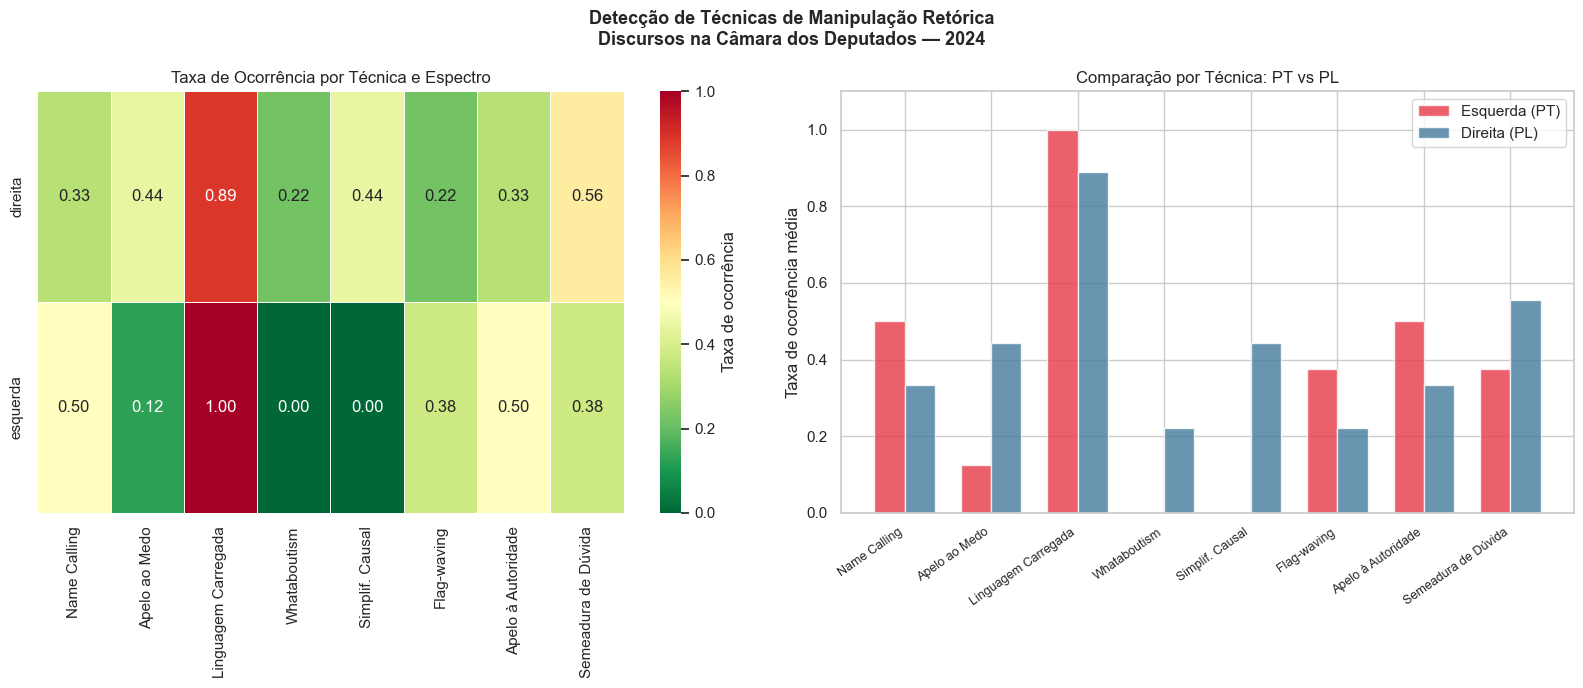

✅ Figura salva em resultados_propaganda_camara.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Detecção de Técnicas de Manipulação Retórica\nDiscursos na Câmara dos Deputados — 2024",
             fontsize=13, fontweight="bold")

cores = {"esquerda": "#E63946", "direita": "#457B9D"}
nomes_legíveis = {
    "name_calling":              "Name Calling",
    "appeal_to_fear":            "Apelo ao Medo",
    "loaded_language":           "Linguagem Carregada",
    "whataboutism":              "Whataboutism",
    "causal_oversimplification": "Simplif. Causal",
    "flag_waving":               "Flag-waving",
    "appeal_to_authority":       "Apelo à Autoridade",
    "doubt":                     "Semeadura de Dúvida",
}

# --- Plot 1: Heatmap de frequência por técnica e espectro ---
ax1 = axes[0]
heat_data = df.groupby("espectro")[colunas_tecnicas].mean()
heat_data.columns = [nomes_legíveis[c] for c in heat_data.columns]
sns.heatmap(heat_data, annot=True, fmt=".2f", cmap="RdYlGn_r",
            ax=ax1, linewidths=0.5, vmin=0, vmax=1,
            cbar_kws={"label": "Taxa de ocorrência"})
ax1.set_title("Taxa de Ocorrência por Técnica e Espectro")
ax1.set_xlabel("")
ax1.set_ylabel("")

# --- Plot 2: Barras agrupadas por técnica ---
ax2 = axes[1]
x = range(len(colunas_tecnicas))
width = 0.35
esq_vals = [df[df.espectro=="esquerda"][t].mean() for t in colunas_tecnicas]
dir_vals = [df[df.espectro=="direita"][t].mean()  for t in colunas_tecnicas]

bars1 = ax2.bar([i - width/2 for i in x], esq_vals, width,
                label="Esquerda (PT)", color=cores["esquerda"], alpha=0.8)
bars2 = ax2.bar([i + width/2 for i in x], dir_vals, width,
                label="Direita (PL)",  color=cores["direita"],  alpha=0.8)

ax2.set_xticks(list(x))
ax2.set_xticklabels([nomes_legíveis[c] for c in colunas_tecnicas],
                    rotation=35, ha="right", fontsize=9)
ax2.set_ylabel("Taxa de ocorrência média")
ax2.set_title("Comparação por Técnica: PT vs PL")
ax2.legend()
ax2.set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig("resultados_propaganda_camara.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figura salva em resultados_propaganda_camara.png")


In [8]:
print("=" * 60)
print("EXEMPLOS DE TÉCNICAS DETECTADAS")
print("=" * 60)

for tecnica in colunas_tecnicas:
    evidencias = df[df[tecnica] == 1][[
        "nome", "partido", f"{tecnica}_evidencia"
    ]].dropna()
    evidencias = evidencias[evidencias[f"{tecnica}_evidencia"] != ""]
    
    if len(evidencias) > 0:
        print(f"\n🔍 {nomes_legíveis[tecnica].upper()} ({len(evidencias)} ocorrências):")
        for _, row in evidencias.head(2).iterrows():
            print(f"   [{row['partido']}] {row['nome']}")
            print(f"   → \"{row[f'{tecnica}_evidencia']}\"")


EXEMPLOS DE TÉCNICAS DETECTADAS

🔍 NAME CALLING (7 ocorrências):
   [PT] Alencar Santana
   → "esse crime e essa traição novamente do Prefeito"
   [PT] Alencar Santana
   → "atitude daquele Presidente omisso e genocida"

🔍 APELO AO MEDO (5 ocorrências):
   [PT] Alexandre Lindenmeyer
   → "trabalhadores de aplicativos... são assaltados e mortos"
   [PL] Alberto Fraga
   → "Milhões de famílias serão destruídas, graças a uma decisão"

🔍 LINGUAGEM CARREGADA (16 ocorrências):
   [PT] Alencar Santana
   → "atropelar a vontade popular, esse crime e essa traição"
   [PT] Alencar Santana
   → "atitude criminosa, evento tão triste e trágico"

🔍 WHATABOUTISM (2 ocorrências):
   [PL] Alberto Fraga
   → "Não adianta falar que o Governo Bolsonaro está incluído"
   [PL] Alberto Fraga
   → "a culpa de tudo isso no Governo da Esquerda"

🔍 SIMPLIF. CAUSAL (4 ocorrências):
   [PL] Alberto Fraga
   → "A culpa da violência é da esquerda"
   [PL] Alberto Fraga
   → "a falta de uma política pública, que não 

## Interpretação e Próximos Passos

### O que este PoC valida
- ✅ **Dados**: API da Câmara é pública, gratuita e retorna transcrições completas
- ✅ **Viabilidade técnica**: LLMs conseguem identificar técnicas com evidências textuais
- ✅ **Diferenças entre partidos**: padrões distintos de uso de técnicas são detectáveis
- ⚠️ **Limitação**: GPT como único anotador — no artigo real, precisamos de anotação humana para validar

### Para o artigo completo
1. **Escalar**: 50-100 deputados, 500+ discursos
2. **Anotação humana**: 2-3 anotadores por trecho + Kappa de Cohen
3. **Múltiplos modelos**: GPT-4o, BERTimbau fine-tunado, LLaMA
4. **Análise temporal**: as técnicas aumentam em períodos eleitorais?
5. **Análise por tema**: segurança pública, economia, saúde — qual tema atrai mais manipulação?

### Referências base
- Da San Martino et al. (2020). *SemEval-2020 Task 11: Detection of Propaganda Techniques in News Articles*. ACL.
- Martino et al. (2019). *Fine-Grained Analysis of Propaganda in News Articles*. EMNLP.
- API Dados Abertos Câmara: https://dadosabertos.camara.leg.br/swagger/api.html


## Validação Cruzada: GPT-4o-mini vs LLaMA 3.2

Para mitigar o risco de viés político do GPT como anotador único,
rodamos o mesmo experimento com LLaMA 3.2 (modelo local, open-source)
e medimos a **concordância entre os dois modelos** via Kappa de Cohen.

Se os dois modelos independentes chegam a padrões similares,
o sinal é mais defensável — não depende de um único modelo proprietário.


In [ ]:
import requests as req
from scipy.stats import chi2_contingency

def detectar_tecnicas_ollama(texto: str, nome: str) -> dict:
    """Usa LLaMA via Ollama local para detectar técnicas de propaganda."""
    
    tecnicas_desc = "\n".join([f"- {k}: {v}" for k, v in TECNICAS.items()])
    
    prompt = f"""Você é um especialista em análise de discurso político e detecção de técnicas de propaganda e manipulação retórica.

Analise o seguinte discurso do deputado {nome} e identifique as técnicas de manipulação retórica presentes.

TÉCNICAS A DETECTAR:
{tecnicas_desc}

DISCURSO:
{texto[:2000]}

Responda APENAS em JSON válido com este formato exato, sem texto adicional:
{{
  "name_calling": {{"presente": 0, "evidencia": ""}},
  "appeal_to_fear": {{"presente": 0, "evidencia": ""}},
  "loaded_language": {{"presente": 0, "evidencia": ""}},
  "whataboutism": {{"presente": 0, "evidencia": ""}},
  "causal_oversimplification": {{"presente": 0, "evidencia": ""}},
  "flag_waving": {{"presente": 0, "evidencia": ""}},
  "appeal_to_authority": {{"presente": 0, "evidencia": ""}},
  "doubt": {{"presente": 0, "evidencia": ""}}
}}"""

    try:
        response = req.post(
            "http://127.0.0.1:11434/api/generate",
            json={
                "model": "llama3.2:3b",
                "prompt": prompt,
                "stream": False,
                "format": "json",
                "options": {"temperature": 0.1}
            },
            timeout=300
        )
        response.raise_for_status()
        raw = response.json().get("response", "{}")
        return json.loads(raw)
    except json.JSONDecodeError:
        import re
        match = re.search(r'\{.*\}', response.json().get("response",""), re.DOTALL)
        if match:
            try:
                return json.loads(match.group())
            except:
                pass
        print(f"    ⚠️  JSON inválido do LLaMA para {nome}")
        return {}
    except Exception as e:
        print(f"    ⚠️  Erro Ollama para {nome}: {e}")
        return {}

# Testa conexão
try:
    test = req.get("http://127.0.0.1:11434/api/tags", timeout=5)
    modelos = [m["name"] for m in test.json().get("models", [])]
    print(f"✅ Ollama conectado. Modelos disponíveis: {modelos}")
except Exception as e:
    print(f"❌ Ollama não acessível: {e}")
    print("   Certifique-se que 'ollama serve' está rodando em outro terminal")


✅ Ollama conectado. Modelos disponíveis: ['llama3.2:3b']


In [15]:
print("⏳ Rodando LLaMA 3.2 nos mesmos discursos...")
print("   (modelo local — sem custo, mas mais lento)\n")

resultados_llama = []
indices_llama_ok = []  # rastreia quais índices foram processados com sucesso

for i, disc in enumerate(todos_discursos):
    print(f"  [{i+1}/{len(todos_discursos)}] {disc['nome']} ({disc['partido']})", end=" ")
    
    tecnicas_detectadas = detectar_tecnicas_ollama(disc["texto"], disc["nome"])
    
    if tecnicas_detectadas:
        row = {
            "nome":     disc["nome"],
            "partido":  disc["partido"],
            "espectro": disc["espectro"],
            "idx_original": i,  # guarda o índice original
        }
        for tecnica in TECNICAS:
            info = tecnicas_detectadas.get(tecnica, {})
            row[tecnica] = info.get("presente", 0)
        
        row["total_tecnicas"] = sum(row[t] for t in TECNICAS)
        resultados_llama.append(row)
        indices_llama_ok.append(i)
        print("✓")
    else:
        print("✗ (falhou)")
    
    time.sleep(0.2)

df_llama = pd.DataFrame(resultados_llama)
print(f"\n✅ LLaMA concluído — {len(df_llama)}/{len(todos_discursos)} discursos processados")
print(f"   Índices com sucesso: {indices_llama_ok}")


⏳ Rodando LLaMA 3.2 nos mesmos discursos...
   (modelo local — sem custo, mas mais lento)

  [1/17] Alencar Santana (PT)     ⚠️  Erro Ollama para Alencar Santana: HTTPConnectionPool(host='127.0.0.1', port=11434): Read timed out. (read timeout=300)
✗ (falhou)
  [2/17] Alencar Santana (PT) ✓
  [3/17] Alencar Santana (PT) ✓
  [4/17] Alencar Santana (PT) ✓
  [5/17] Alencar Santana (PT) ✓
  [6/17] Alexandre Lindenmeyer (PT) ✓
  [7/17] Alexandre Lindenmeyer (PT) ✓
  [8/17] Alexandre Lindenmeyer (PT) ✓
  [9/17] Alberto Fraga (PL) ✓
  [10/17] Alberto Fraga (PL)     ⚠️  Erro Ollama para Alberto Fraga: HTTPConnectionPool(host='127.0.0.1', port=11434): Read timed out. (read timeout=300)
✗ (falhou)
  [11/17] Alberto Fraga (PL) ✓
  [12/17] Alberto Fraga (PL) ✓
  [13/17] Alberto Fraga (PL)     ⚠️  Erro Ollama para Alberto Fraga: HTTPConnectionPool(host='127.0.0.1', port=11434): Read timed out. (read timeout=300)
✗ (falhou)
  [14/17] André Fernandes (PL) ✓
  [15/17] André Fernandes (PL)     ⚠️  Erro 

In [ ]:
from sklearn.metrics import cohen_kappa_score

print("=" * 60)
print("CONCORDÂNCIA ENTRE GPT-4o-mini E LLaMA 3.2")
print("=" * 60)

# Alinha pelo índice original — só compara discursos que AMBOS processaram
df_gpt_aligned   = df.iloc[indices_llama_ok].reset_index(drop=True)
df_llama_aligned = df_llama.reset_index(drop=True)

print(f"\nDiscursos comparados: {len(df_gpt_aligned)} (de {len(df)} GPT / {len(df_llama)} LLaMA)")
kappas = {}
print(f"\n{'Técnica':<30} {'Kappa':>8}  {'Concordância':>14}  {'GPT%':>6}  {'LLaMA%':>7}")
print("-" * 70)

for tecnica in TECNICAS:
    gpt_labels   = df_gpt_aligned[tecnica].values
    llama_labels = df_llama_aligned[tecnica].values
    
    # Concordância simples
    concordancia = (gpt_labels == llama_labels).mean()
    
    # Kappa de Cohen — métrica de concordância entre classificadores
    try:
        kappa = cohen_kappa_score(gpt_labels, llama_labels)
    except:
        kappa = float('nan')
    
    kappas[tecnica] = kappa
    
    gpt_pct   = gpt_labels.mean()
    llama_pct = llama_labels.mean()
    
    nome_leg = nomes_legíveis.get(tecnica, tecnica)
    print(f"{nome_leg:<30} {kappa:>8.3f}  {concordancia:>13.1%}  {gpt_pct:>5.1%}  {llama_pct:>6.1%}")

kappa_medio = pd.Series(kappas).dropna().mean()
print(f"\n{'Kappa médio':<30} {kappa_medio:>8.3f}")
print(f"\nInterpretação do Kappa:")
print(f"  < 0.20  → fraca    |  0.20–0.40 → razoável")
print(f"  0.40–0.60 → moderada |  0.60–0.80 → boa  |  > 0.80 → excelente")

if kappa_medio > 0.4:
    print(f"\nConcordância moderada/boa — o sinal é consistente entre modelos")
else:
    print(f"\n Concordância baixa — os modelos divergem bastante")
    print(f"   Isso em si é um resultado interessante para o artigo!")


CONCORDÂNCIA ENTRE GPT-4o-mini E LLaMA 3.2

Discursos comparados: 12 (de 17 GPT / 12 LLaMA)

Técnica                           Kappa    Concordância    GPT%   LLaMA%
----------------------------------------------------------------------
Name Calling                      0.308          75.0%  33.3%    8.3%
Apelo ao Medo                     0.429          83.3%  25.0%    8.3%
Linguagem Carregada              -0.125          75.0%  91.7%   83.3%
Whataboutism                     -0.091          83.3%   8.3%    8.3%
Simplif. Causal                   0.182          50.0%  16.7%   66.7%
Flag-waving                       0.143          66.7%  33.3%   16.7%
Apelo à Autoridade                0.000          58.3%  41.7%    0.0%
Semeadura de Dúvida              -0.312          41.7%  41.7%   16.7%

Kappa médio                       0.067

Interpretação do Kappa:
  < 0.20  → fraca    |  0.20–0.40 → razoável
  0.40–0.60 → moderada |  0.60–0.80 → boa  |  > 0.80 → excelente

⚠️  Concordância baixa — o

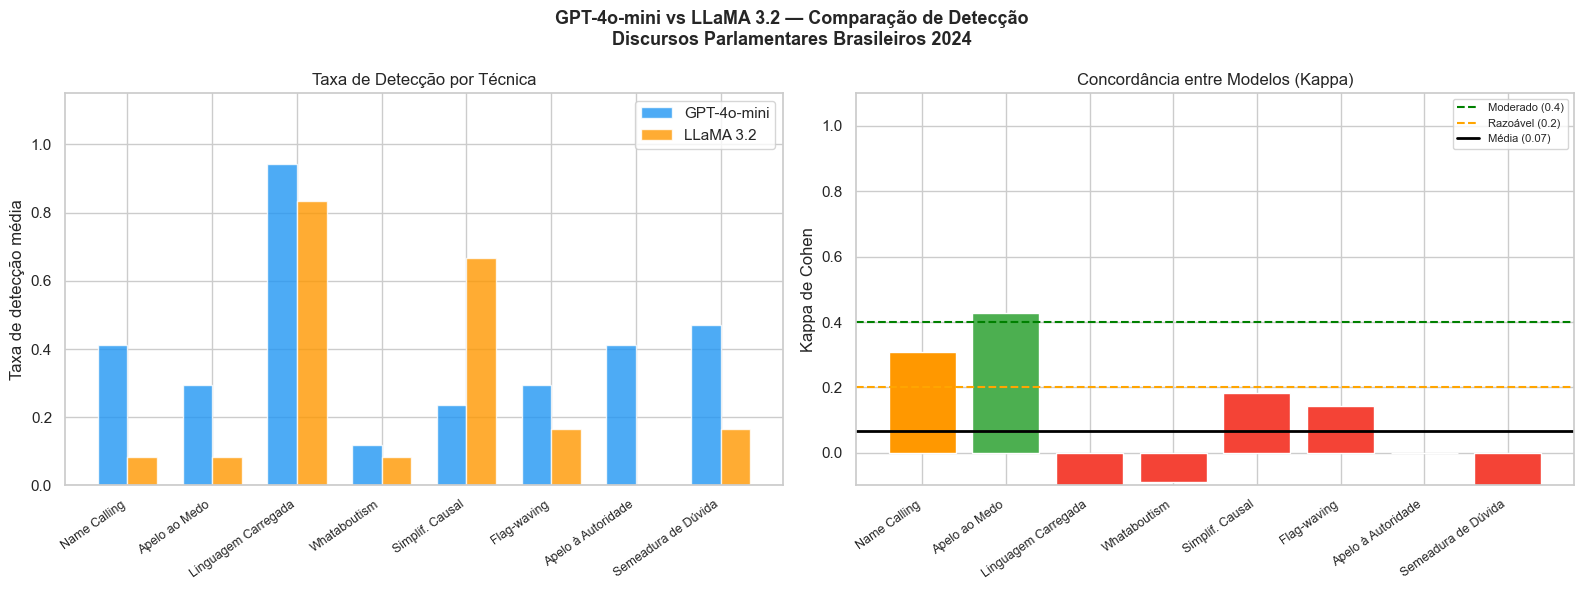

✅ Figura salva em comparacao_gpt_llama.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("GPT-4o-mini vs LLaMA 3.2 — Comparação de Detecção\nDiscursos Parlamentares Brasileiros 2024",
             fontsize=13, fontweight="bold")

nomes_leg = [nomes_legíveis[t] for t in TECNICAS]

# --- Plot 1: Taxa de detecção por técnica, GPT vs LLaMA ---
ax1 = axes[0]
x = range(len(TECNICAS))
w = 0.35
gpt_rates   = [df[t].mean()       for t in TECNICAS]
llama_rates = [df_llama[t].mean() for t in TECNICAS]

ax1.bar([i - w/2 for i in x], gpt_rates,   w, label="GPT-4o-mini",  color="#2196F3", alpha=0.8)
ax1.bar([i + w/2 for i in x], llama_rates, w, label="LLaMA 3.2",    color="#FF9800", alpha=0.8)
ax1.set_xticks(list(x))
ax1.set_xticklabels(nomes_leg, rotation=35, ha="right", fontsize=9)
ax1.set_ylabel("Taxa de detecção média")
ax1.set_title("Taxa de Detecção por Técnica")
ax1.legend()
ax1.set_ylim(0, 1.15)

# --- Plot 2: Kappa por técnica ---
ax2 = axes[1]
kappa_vals = [kappas.get(t, 0) for t in TECNICAS]
cores_kappa = ["#4CAF50" if k > 0.4 else "#FF9800" if k > 0.2 else "#F44336"
               for k in kappa_vals]
bars = ax2.bar(nomes_leg, kappa_vals, color=cores_kappa, edgecolor="white")
ax2.axhline(0.4, color="green",  linestyle="--", linewidth=1.5, label="Moderado (0.4)")
ax2.axhline(0.2, color="orange", linestyle="--", linewidth=1.5, label="Razoável (0.2)")
ax2.axhline(kappa_medio, color="black", linestyle="-", linewidth=2,
            label=f"Média ({kappa_medio:.2f})")
ax2.set_xticklabels(nomes_leg, rotation=35, ha="right", fontsize=9)
ax2.set_ylabel("Kappa de Cohen")
ax2.set_title("Concordância entre Modelos (Kappa)")
ax2.legend(fontsize=8)
ax2.set_ylim(-0.1, 1.1)

plt.tight_layout()
plt.savefig("comparacao_gpt_llama.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figura salva em comparacao_gpt_llama.png")


## O que a concordância significa para o artigo

### Se Kappa > 0.4 (moderado ou melhor):
Os dois modelos — um proprietário (GPT) e um open-source local (LLaMA) —
chegam a conclusões similares **de forma independente**.
Isso fortalece muito o argumento de que o sinal é real,
não um artefato de um modelo específico.

### Se Kappa < 0.4 (fraco):
Também é um resultado interessante! Significa que modelos diferentes
"enxergam" manipulação retórica de formas distintas — o que levanta
a questão: qual deles está mais alinhado com julgamento humano?
Isso motiva diretamente a necessidade de anotação humana como ground truth.

### Em ambos os casos, você tem material para o artigo.
A comparação GPT vs LLaMA é o **experimento piloto**.
O artigo completo adiciona o terceiro elemento: **anotação humana**.


## Discussão Metodológica e Estatística

### 1. Desenho do experimento

Este experimento piloto tem como objetivo avaliar a **viabilidade técnica** da detecção
automática de técnicas de manipulação retórica em discursos parlamentares brasileiros,
e não produzir resultados conclusivos. As escolhas metodológicas refletem esse escopo.

**Corpus:**
- Fonte: API de Dados Abertos da Câmara dos Deputados (`dadosabertos.camara.leg.br`)
- Período: março–junho de 2024 (legislatura atual)
- Deputados: 4 (2 PT, 2 PL), selecionados por disponibilidade de discursos no período
- Discursos coletados: 17 (GPT) / 12 alinhados (comparação GPT vs. LLaMA)
- Tamanho dos trechos: até 3.000 caracteres por discurso

**Limitação crítica de amostra:**
N=12 discursos alinhados é insuficiente para inferência estatística robusta.
O poder estatístico mínimo recomendado para testes de concordância exige N≥30.
Os resultados aqui apresentados são **exploratórios** e servem apenas para
orientar o desenho do estudo completo.

---

### 2. Por que Kappa de Cohen?

O **Kappa de Cohen (κ)** é a métrica padrão para medir concordância entre dois
anotadores em tarefas de classificação categórica, descontando a concordância
esperada por acaso.

**Fórmula:**
κ = (Po − Pe) / (1 − Pe)

Onde:
- **Po** = proporção de concordância observada
- **Pe** = proporção de concordância esperada por acaso

**Por que não usar apenas % de concordância?**
Concordância simples é enganosa em classes desbalanceadas. Por exemplo:
se uma técnica aparece em apenas 8% dos discursos, um modelo que **nunca**
a detecta ainda teria 92% de concordância com outro modelo que também nunca
a detecta — mas o Kappa seria 0 (sem concordância real).

**Interpretação (Landis & Koch, 1977):**
| κ | Interpretação |
|---|---|
| < 0.00 | Sem concordância (pior que o acaso) |
| 0.00–0.20 | Fraca |
| 0.21–0.40 | Razoável |
| 0.41–0.60 | Moderada |
| 0.61–0.80 | Boa |
| 0.81–1.00 | Quase perfeita |

---

### 3. Resultados e interpretação

**Kappa médio: κ = 0.067 (fraco)**

Os modelos concordam pouco além do acaso na maioria das técnicas.
Isso é um resultado científico relevante, não uma falha do experimento.

**Análise por técnica:**

| Técnica | κ | Interpretação | Observação |
|---|---|---|---|
| Apelo ao Medo | 0.429 | **Moderada** ✓ | Único consenso real entre os modelos |
| Name Calling | 0.308 | Razoável | GPT detecta 4x mais que LLaMA |
| Simplif. Causal | 0.182 | Fraca | LLaMA detecta 4x mais que GPT |
| Flag-waving | 0.143 | Fraca | Divergência moderada |
| Apelo à Autoridade | 0.000 | Sem concordância | LLaMA nunca detecta (0%) |
| Whataboutism | -0.091 | Pior que acaso | Ambos detectam pouco, mas diferente |
| Linguagem Carregada | -0.125 | Pior que acaso | Ambos detectam muito, mas diferente |
| Semeadura de Dúvida | -0.312 | Pior que acaso | Maior divergência do experimento |

**Kappas negativos** ocorrem quando os modelos discordam mais do que seria
esperado por acaso — geralmente em técnicas onde um modelo detecta muito
e o outro detecta pouco (ex: Linguagem Carregada: GPT=91.7%, LLaMA=83.3%,
mas em discursos *diferentes*).

---

### 4. Trade-offs e limitações

**Trade-off 1 — Modelo vs. anotador humano:**
GPT-4o-mini e LLaMA 3.2 são usados aqui como **anotadores automáticos**,
não como classificadores avaliados contra um ground truth. Isso é uma limitação
fundamental: não sabemos qual modelo está "certo". O estudo completo
resolveria isso com anotação humana como referência.

**Trade-off 2 — Tamanho do modelo:**
LLaMA 3.2:3b é um modelo pequeno (3 bilhões de parâmetros) rodando localmente,
enquanto GPT-4o-mini é um modelo muito maior acessado via API. A diferença de
capacidade pode explicar parte da divergência — não necessariamente viés político.

**Trade-off 3 — Prompt único:**
Ambos os modelos receberam o mesmo prompt. LLMs são sensíveis à formulação
do prompt (fenômeno documentado como *prompt sensitivity*). Resultados podem
variar com prompts diferentes — o estudo completo testaria múltiplas formulações.

**Trade-off 4 — Amostra desbalanceada:**
Os 12 discursos alinhados têm 8 do PT e 4 do PL (por conta dos timeouts do LLaMA
nos discursos do PL). Isso introduz viés na comparação por espectro político.

---

### 5. O que esses resultados justificam

A baixa concordância entre GPT e LLaMA **não invalida** o experimento —
ela **motiva** as três perguntas de pesquisa do artigo:

- **PQ1**: LLMs conseguem detectar técnicas? → *Sim, mas com calibrações muito diferentes*
- **PQ2**: Fine-tuning supera zero-shot? → *A divergência entre modelos sugere que sim*
- **PQ3**: Os detectores têm viés político? → *Não podemos saber sem ground truth humano*

O estudo completo adicionaria: (1) amostra ≥ 500 discursos, (2) anotação humana
com ≥ 3 anotadores, (3) cálculo de Kappa inter-anotadores humanos como baseline,
(4) fine-tuning do BERTimbau no dataset anotado, e (5) comparação sistemática
dos três modelos contra o ground truth.
